### Import Library

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

### Read CSV File

In [ ]:
df = pd.read_csv('../data/data.csv')

### 1. Inspect dataset size, structure, and data types.
#### Dataset Size

In [ ]:
print("Number of row and columns:", df.shape)
print("Column names:", df.columns.tolist())
print("Number of rows:", len(df))

Number of row and columns: (48842, 15)
Column names: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Number of rows: 48842


In [ ]:
print("Data Information:")
print("=" * 50)
print(df.info())

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB
None


##### Data Type

In [ ]:
print("Numerical columns:")
numerical_data = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_data)

Numerical columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [ ]:
print("Categorical columns:")
categorical_data = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_data)

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### Dataset Structure

In [ ]:
print("Categorical:")
df[categorical_data].head()

Categorical:


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [ ]:
print("Numerical:")
df[numerical_data].head()

Numerical:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


### 2. Identify missing values and anomalies

In [ ]:
print("Missing values in each column:")
print(df.isna().sum())

Missing values in each column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


In [ ]:
print("Missing values of each column in percentage:")
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].round(2).astype(str) + "%")

Missing values of each column in percentage:
workclass         1.97%
occupation        1.98%
native-country    0.56%
dtype: str


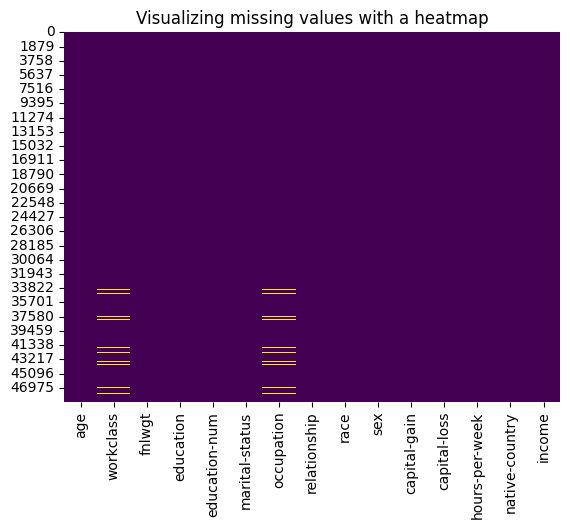

In [ ]:
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Visualizing missing values with a heatmap")
plt.show()

#### Drop the missing value

In [ ]:
df.dropna(inplace=True)

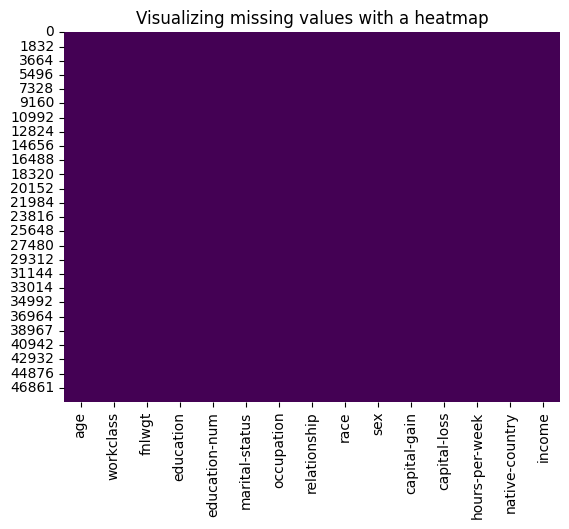

In [ ]:
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Visualizing missing values with a heatmap")
plt.show()

Duplicated rows

In [ ]:
df.duplicated().sum()

np.int64(29)

Outliers

In [ ]:
print("Identifying ananomalies in numerical columns:")
Q1 = df[numerical_data].quantile(0.25)
Q3 = df[numerical_data].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[numerical_data] < lower_bound) | (df[numerical_data] > upper_bound)]
outliers.count()

Identifying ananomalies in numerical columns:


age                 200
workclass             0
fnlwgt             1413
education             0
education-num      1723
marital-status        0
occupation            0
relationship          0
race                  0
sex                   0
capital-gain       3964
capital-loss       2232
hours-per-week    12954
native-country        0
income                0
dtype: int64

In [ ]:
# percentage of outliers in each numerical column
outlier_percent = (outliers.count() / len(df)) * 100
print(outlier_percent.round(2).astype(str) + "%")

age               0.42%
workclass          0.0%
fnlwgt            2.97%
education          0.0%
education-num     3.62%
marital-status     0.0%
occupation         0.0%
relationship       0.0%
race               0.0%
sex                0.0%
capital-gain      8.32%
capital-loss      4.69%
hours-per-week    27.2%
native-country     0.0%
income             0.0%
dtype: str


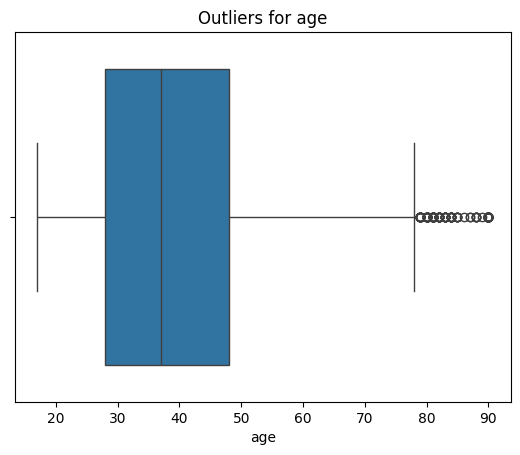

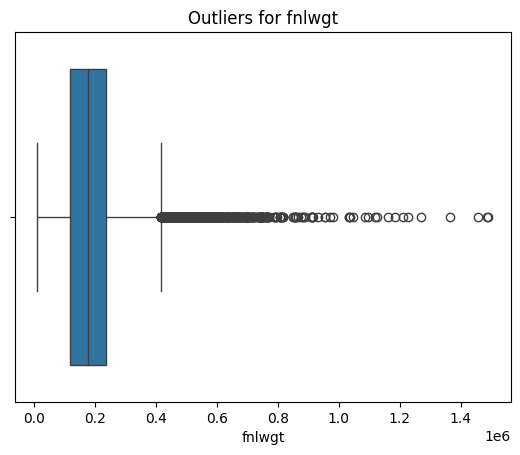

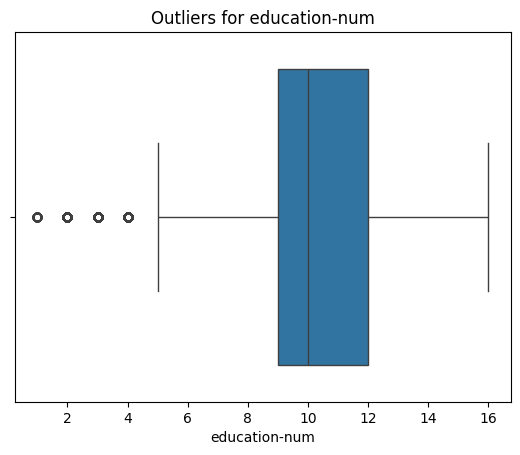

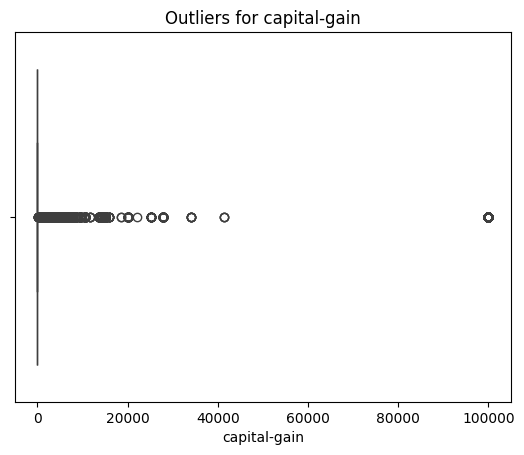

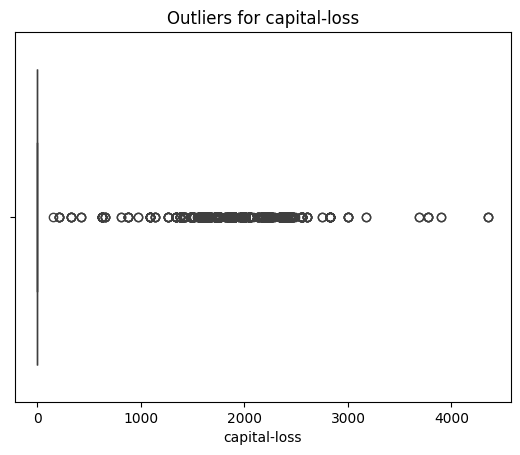

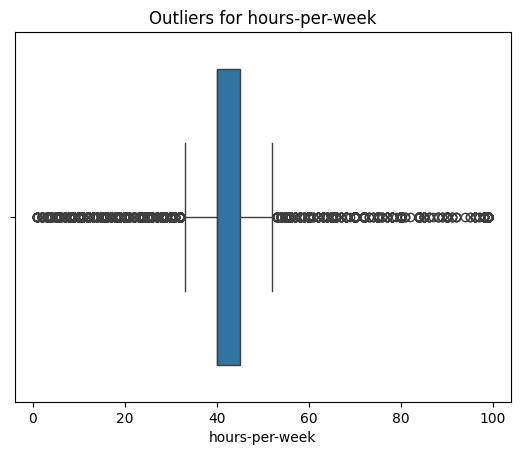

In [ ]:
for i in numerical_data:
    sns.boxplot(x=df[i])
    plt.title(f'Outliers for {i}')
    plt.show()

#### Cleaning outliers of age, capital-gain, capital-loss, and hours-per-week

In [ ]:
# cleaning outliers of age using IQR method
age_Q1 = np.quantile(df['age'], 0.25)
age_Q3 = np.quantile(df['age'], 0.75)
age_IQR = age_Q3 - age_Q1
age_lower_bound = age_Q1 - 1.5 * age_IQR
age_upper_bound = age_Q3 + 1.5 * age_IQR
df = df[(df['age'] >= age_lower_bound) & (df['age'] <= age_upper_bound)]

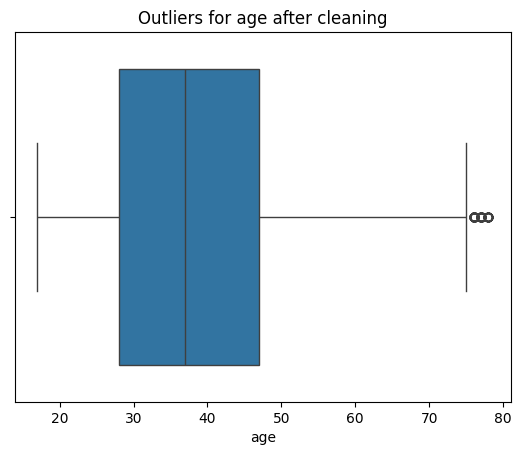

In [ ]:
sns.boxplot(x=df['age'])
plt.title('Outliers for age after cleaning')
plt.show()

In [ ]:
# Drop column fnlwgt as it is not relevant for salary prediction
df.drop(columns=['fnlwgt'], inplace=True)

In [ ]:
# transform outliers of capital-gain and capital-loss using log
df['capital-gain'] = np.log1p(df['capital-gain'])
df['capital-loss'] = np.log1p(df['capital-loss'])

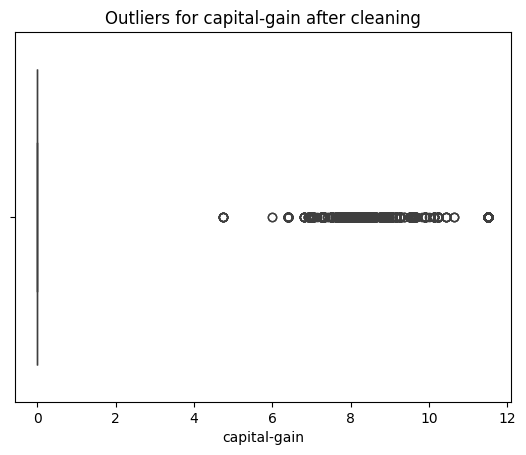

In [ ]:
sns.boxplot(x=df['capital-gain'])
plt.title('Outliers for capital-gain after cleaning')
plt.show()

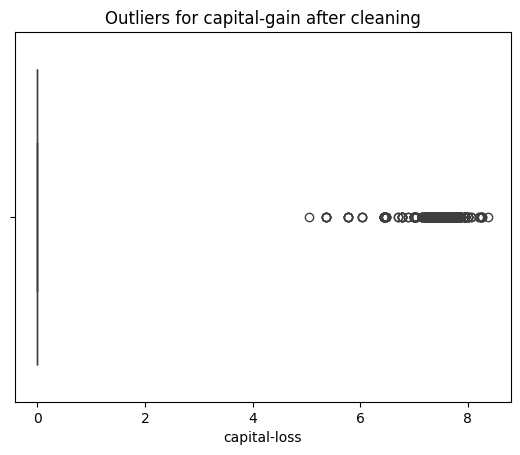

In [ ]:
sns.boxplot(x=df['capital-loss'])
plt.title('Outliers for capital-gain after cleaning')
plt.show()

In [ ]:
df['hours-per-week'] = df['hours-per-week'].clip(upper=80)

<Axes: xlabel='hours-per-week'>

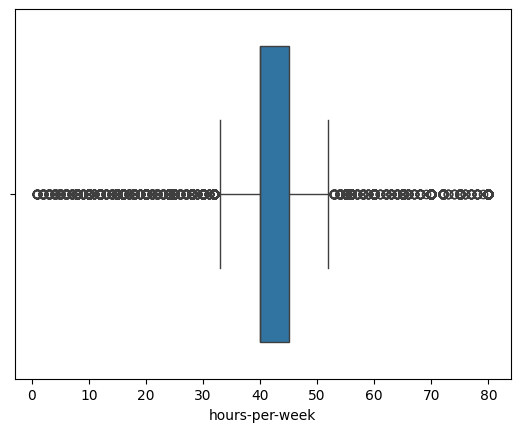

In [ ]:
sns.boxplot(x=df['hours-per-week'])

Fix inconsistent categorical variables

In [ ]:
df[categorical_data].nunique()

workclass          9
education         16
marital-status     7
occupation        15
relationship       6
race               5
sex                2
native-country    42
income             4
dtype: int64

In [ ]:
for col in categorical_data:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for workclass:
workclass
Private             33622
Self-emp-not-inc     3800
Local-gov            3113
State-gov            1964
?                    1801
Self-emp-inc         1673
Federal-gov          1420
Without-pay            21
Never-worked            7
Name: count, dtype: int64


Value counts for education:
education
HS-grad         15378
Some-college    10488
Bachelors        7857
Masters          2598
Assoc-voc        2029
11th             1740
Assoc-acdm       1561
10th             1331
7th-8th           888
Prof-school       808
9th               733
12th              631
Doctorate         578
5th-6th           489
1st-4th           234
Preschool          78
Name: count, dtype: int64


Value counts for marital-status:
marital-status
Married-civ-spouse       21873
Never-married            15526
Divorced                  6516
Separated                 1495
Widowed                   1382
Married-spouse-absent      595
Married-AF-spouse           34
Name: count, dtyp

In [ ]:
for col in categorical_data:
    print(f"Value counts for {col}:")
    print(df[col].value_counts() / len(df) * 100)
    print("\n")

Value counts for workclass:
workclass
Private             70.901078
Self-emp-not-inc     8.013327
Local-gov            6.564602
State-gov            4.141625
?                    3.797895
Self-emp-inc         3.527973
Federal-gov          2.994454
Without-pay          0.044284
Never-worked         0.014761
Name: count, dtype: float64


Value counts for education:
education
HS-grad         32.428671
Some-college    22.116784
Bachelors       16.568609
Masters          5.478585
Assoc-voc        4.278695
11th             3.669260
Assoc-acdm       3.291791
10th             2.806773
7th-8th          1.872588
Prof-school      1.703886
9th              1.545729
12th             1.330634
Doctorate        1.218869
5th-6th          1.031189
1st-4th          0.493452
Preschool        0.164484
Name: count, dtype: float64


Value counts for marital-status:
marital-status
Married-civ-spouse       46.125134
Never-married            32.740769
Divorced                 13.740748
Separated                

In [ ]:
df[df['workclass'] == "?"].head(10)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27,54,?,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0.000000,0.0,60,South,>50K
61,32,?,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0.000000,0.0,40,?,<=50K
69,25,?,Some-college,10,Never-married,?,Own-child,White,Male,0.000000,0.0,40,United-States,<=50K
77,67,?,10th,6,Married-civ-spouse,?,Husband,White,Male,0.000000,0.0,2,United-States,<=50K
106,17,?,10th,6,Never-married,?,Own-child,White,Female,10.436935,0.0,32,United-States,<=50K
128,35,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0.000000,0.0,40,United-States,<=50K
149,43,?,Some-college,10,Divorced,?,Not-in-family,White,Female,0.000000,0.0,40,United-States,<=50K
154,52,?,HS-grad,9,Divorced,?,Not-in-family,White,Male,0.000000,0.0,45,United-States,>50K
160,68,?,1st-4th,2,Divorced,?,Not-in-family,White,Female,0.000000,0.0,20,United-States,<=50K
187,53,?,Bachelors,13,Divorced,?,Not-in-family,White,Female,0.000000,0.0,50,United-States,<=50K


In [ ]:
df[df['workclass'] == "?"].tail(10)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32335,18,?,11th,7,Never-married,?,Own-child,White,Female,0.0,0.0,25,United-States,<=50K
32343,66,?,HS-grad,9,Widowed,?,Unmarried,White,Female,0.0,0.0,40,United-States,<=50K
32426,20,?,HS-grad,9,Never-married,?,Own-child,White,Male,0.0,0.0,40,United-States,<=50K
32477,49,?,12th,8,Divorced,?,Other-relative,Black,Male,0.0,0.0,40,United-States,<=50K
32490,60,?,9th,5,Divorced,?,Not-in-family,Black,Male,0.0,0.0,35,United-States,<=50K
32530,35,?,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0.0,0.0,55,United-States,>50K
32531,30,?,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0.0,0.0,80,United-States,<=50K
32539,71,?,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,10,United-States,>50K
32541,41,?,HS-grad,9,Separated,?,Not-in-family,Black,Female,0.0,0.0,32,United-States,<=50K
32542,72,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0.0,0.0,25,United-States,<=50K


In [ ]:
df = df[(df['workclass'] != "?") & (df['occupation'] != "?") & (df['native-country'] != "?")]

In [ ]:
df['income'] = df['income'].str.replace(".", "")

In [ ]:
for col in categorical_data:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for workclass:
workclass
Private             33214
Self-emp-not-inc     3758
Local-gov            3087
State-gov            1945
Self-emp-inc         1631
Federal-gov          1403
Without-pay            21
Name: count, dtype: int64


Value counts for education:
education
HS-grad         14732
Some-college     9878
Bachelors        7549
Masters          2504
Assoc-voc        1956
11th             1613
Assoc-acdm       1504
10th             1219
7th-8th           802
Prof-school       777
9th               674
12th              575
Doctorate         540
5th-6th           446
1st-4th           218
Preschool          72
Name: count, dtype: int64


Value counts for marital-status:
marital-status
Married-civ-spouse       20978
Never-married            14571
Divorced                  6289
Separated                 1410
Widowed                   1232
Married-spouse-absent      547
Married-AF-spouse           32
Name: count, dtype: int64


Value counts for occupation:
occupation
C